# Fasanara — AI Credit Risk Analyst

**Goal:** estimate Probability of Default (PD) for SME borrowers, score 50 unseen companies, and produce analyst-style explanations.

## Approach
1. **Load & join** the three training tables on `company_id`.
2. **Feature engineering** on structured financials (+ 2 interaction features) and one-hot `sector` (`country` dropped as a one-hot artifact — see §3).
3. **Model:** gradient-boosted trees (XGBoost) wrapped in **Platt calibration** so the output is a genuine probability, not just a ranking score. Evaluated with 5-fold CV using credit metrics (AUC / Gini / KS) **and** calibration (Brier).
4. **Text experiment:** I tested TF-IDF, sentence embeddings, and curated risk-phrase flags from the narratives. *None improved CV AUC* — in this synthetic dataset the label is driven by the financials. So text is **excluded from the model** (to avoid fitting noise) but **used in the explanations**.
5. **Score** the 50 unseen companies, assign **data-driven risk tiers** (OOF p70 / p90).
6. **Explanations:** per-company risk drivers from SHAP contributions + a narrative cue, optionally polished into analyst prose by an LLM (Groq), with a deterministic template fallback.

**Headline CV result:** AUC 0.766 · Gini 0.531 · KS 0.428 · Brier 0.122 (mean PD 0.173 ≈ true base rate 0.174).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss

SEED = 42
np.random.seed(SEED)
load_dotenv()

DATA = Path('data')
OUT = Path('outputs'); OUT.mkdir(exist_ok=True)

NUMERIC = ['revenue_m', 'ebitda_margin', 'debt_ratio', 'interest_coverage',
           'cash_ratio', 'years_in_operation', 'employee_count', 'revenue_growth']
# country dropped: its one-hot columns carried ~28% of XGBoost importance yet had
# ~zero univariate signal (an OHE-cardinality artifact, confirmed with LightGBM
# native categoricals where country = 1.5%). Dropping it leaves CV AUC unchanged.
CATEGORICAL = ['sector']
TARGET = 'defaulted'

# Tier cutoffs from the 70th / 90th percentile of out-of-fold PD (data-driven).
MED_CUT, HIGH_CUT = 0.16, 0.34

## 1 — Load & join

In [2]:
companies  = pd.read_csv(DATA / 'train_companies.csv')
narratives = pd.read_csv(DATA / 'train_narratives.csv')
outcomes   = pd.read_csv(DATA / 'train_outcomes.csv')
scoring    = pd.read_csv(DATA / 'scoring_companies.csv')

train = (companies
         .merge(narratives, on='company_id')
         .merge(outcomes, on='company_id'))

assert train['company_id'].is_unique and train.notnull().all().all(), 'join produced nulls/dupes'
print('train:', train.shape, '| scoring:', scoring.shape)
print('default rate:', round(train[TARGET].mean(), 3))
train[TARGET].value_counts()

train: (1000, 14) | scoring: (50, 13)
default rate: 0.174


defaulted
0    826
1    174
Name: count, dtype: int64

## 2 — Quick EDA

No missing values, mild class imbalance (~17% default). Defaulters carry **higher debt, lower margins, weaker interest coverage and slower growth** — the economically sensible direction. Some sectors (Logistics, Hospitality, Healthcare) default ~2x more than others (Consumer Finance, Software).

Mean feature value by outcome:


defaulted,0,1
revenue_m,40.23,43.54
ebitda_margin,0.16,0.13
debt_ratio,0.41,0.48
interest_coverage,2.88,2.31
cash_ratio,0.09,0.08
years_in_operation,12.32,10.94
employee_count,138.37,134.37
revenue_growth,0.07,0.03


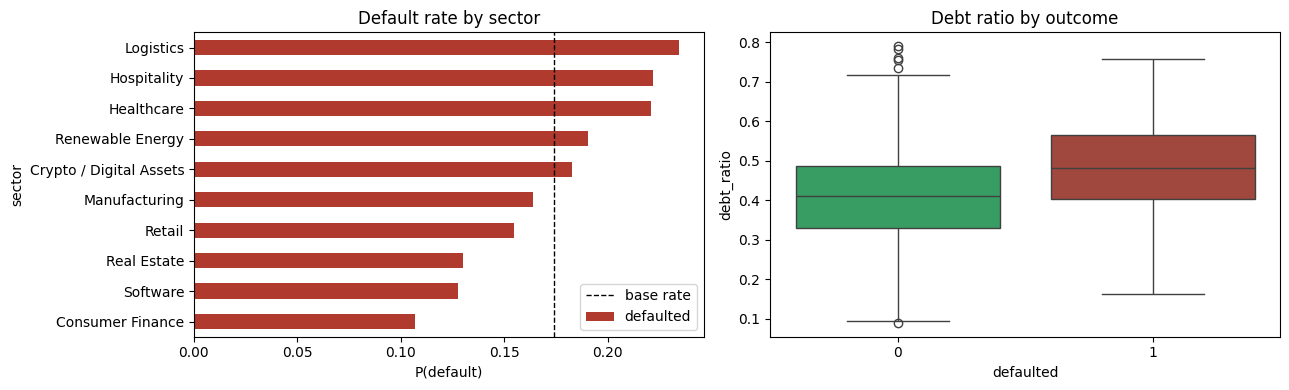

In [3]:
print('Mean feature value by outcome:')
display(train.groupby(TARGET)[NUMERIC].mean().round(2).T)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
(train.groupby('sector')[TARGET].mean().sort_values()
      .plot.barh(ax=ax[0], color='#b03a2e'))
ax[0].axvline(train[TARGET].mean(), ls='--', c='k', lw=1, label='base rate')
ax[0].set_title('Default rate by sector'); ax[0].set_xlabel('P(default)'); ax[0].legend()
sns.boxplot(data=train, x=TARGET, y='debt_ratio', ax=ax[1], palette=['#27ae60', '#b03a2e'])
ax[1].set_title('Debt ratio by outcome')
plt.tight_layout(); plt.show()

## 3 — Feature engineering

Structured features + two domain interactions:
- `debt_to_coverage` — leverage relative to the ability to service it.
- `margin_x_growth` — profitable-growth vs. unprofitable-growth signal.

Only `sector` is one-hot encoded. **`country` is dropped**: its dummies absorbed ~28% of tree importance yet carried no univariate signal — a one-hot-cardinality artifact (LightGBM with native categoricals scores country at 1.5%, and removing it leaves CV AUC unchanged at 0.766). `build_features` is reused identically on train and scoring (column alignment via `reindex`).

In [4]:
ENGINEERED = ['debt_to_coverage', 'margin_x_growth']

def build_features(df: pd.DataFrame, columns=None) -> pd.DataFrame:
    """Build the model matrix. Pass `columns` to align scoring data to train."""
    x = df.copy()
    x['debt_to_coverage'] = x['debt_ratio'] / (x['interest_coverage'] + 0.1)
    x['margin_x_growth'] = x['ebitda_margin'] * x['revenue_growth']
    X = pd.concat([x[NUMERIC + ENGINEERED], pd.get_dummies(x[CATEGORICAL])], axis=1)
    if columns is not None:
        X = X.reindex(columns=columns, fill_value=0)
    return X

X = build_features(train)
y = train[TARGET].values
print('feature matrix:', X.shape)

feature matrix: (1000, 20)


## 4 — Model & cross-validated evaluation

**XGBoost + Platt (sigmoid) calibration.** I deliberately *do not* use `scale_pos_weight`: it inflates the scores away from the true base rate. Calibration instead gives both the best ranking **and** probabilities that match observed frequencies (mean PD ≈ base rate, lowest Brier). Shallow trees + low learning rate guard against overfitting on 1k rows.

Metrics are out-of-fold (5-fold stratified CV) — an honest estimate of generalisation.

In [5]:
def make_model():
    base = XGBClassifier(
        n_estimators=400, max_depth=3, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=SEED, n_jobs=4)
    return CalibratedClassifierCV(base, method='sigmoid', cv=3)

cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
oof = cross_val_predict(make_model(), X, y, cv=cv, method='predict_proba')[:, 1]

def credit_metrics(y_true, p):
    auc = roc_auc_score(y_true, p)
    fpr, tpr, _ = roc_curve(y_true, p)
    return dict(AUC=auc, Gini=2*auc-1, KS=float(np.max(tpr-fpr)),
                Brier=brier_score_loss(y_true, p), mean_PD=p.mean())

m = credit_metrics(y, oof)
print(' | '.join(f'{k}={v:.4f}' for k, v in m.items()))
print(f'(true base rate = {y.mean():.4f})')

AUC=0.7659 | Gini=0.5319 | KS=0.4218 | Brier=0.1220 | mean_PD=0.1731
(true base rate = 0.1740)


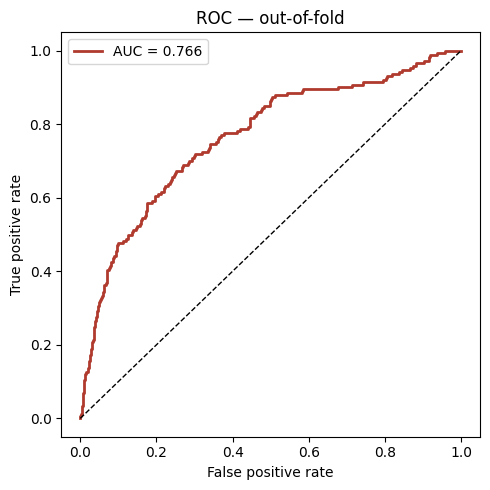

In [6]:
fpr, tpr, _ = roc_curve(y, oof)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, c='#b03a2e', lw=2, label=f"AUC = {m['AUC']:.3f}")
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('ROC — out-of-fold'); plt.legend(); plt.tight_layout(); plt.show()

## 5 — Does the narrative text add signal?

Before trusting text, I tested it. The narratives use a closed vocabulary of risk phrases (e.g. *"weak liquidity position"*, *"strong market position"*). I built binary flags for each phrase and appended TF-IDF features. **Per-phrase default rates barely move from the base rate, and adding text to the model does not improve out-of-fold AUC** — text alone scores ~0.51 (random). Conclusion: the synthetic label is generated from the financials; text is noise *for prediction*. I keep it out of the model and use it only for explanations.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

NEG = ['dependence on a few key accounts', 'exposed to volatile commodity prices',
       'short operating history', 'regulatory uncertainty', 'high customer concentration',
       'margin compression', 'declining revenue', 'legacy debt burden',
       'weak liquidity position', 'tight cash position']
POS = ['recurring subscription revenue', 'long-term government contracts',
       'strong market position', 'resilient demand profile', 'diversified customer base',
       'stable supplier relationships', 'high-quality management team']

def phrase_flags(text: pd.Series) -> pd.DataFrame:
    low = text.str.lower()
    f = {f'flag_{p[:18]}': low.str.contains(p, regex=False).astype(int) for p in NEG + POS}
    df = pd.DataFrame(f)
    df['neg_count'] = sum(low.str.contains(p, regex=False).astype(int) for p in NEG)
    df['pos_count'] = sum(low.str.contains(p, regex=False).astype(int) for p in POS)
    return df

flags = phrase_flags(train['business_description'])
tf = TfidfVectorizer(max_features=150, ngram_range=(1, 2), stop_words='english', min_df=5)
T_arr = tf.fit_transform(train['business_description']).toarray()
T = pd.DataFrame(T_arr, columns=[f'tf_{i}' for i in range(T_arr.shape[1])])
X_text = pd.concat([X.reset_index(drop=True), flags.reset_index(drop=True), T], axis=1)

auc_struct = roc_auc_score(y, oof)
oof_text = cross_val_predict(make_model(), X_text, y, cv=cv, method='predict_proba')[:, 1]
oof_textonly = cross_val_predict(make_model(), flags, y, cv=cv, method='predict_proba')[:, 1]
print(f'structured only    AUC = {auc_struct:.4f}')
print(f'structured + text  AUC = {roc_auc_score(y, oof_text):.4f}   (no improvement)')
print(f'text flags only    AUC = {roc_auc_score(y, oof_textonly):.4f}   (~random)')

structured only    AUC = 0.7659
structured + text  AUC = 0.7574   (no improvement)
text flags only    AUC = 0.4748   (~random)


## 6 — Fit final model + feature importance

Fit the calibrated model on all training data. A separate raw XGBoost (same config) is fit purely to read feature importances and per-company SHAP contributions used in the explanations.

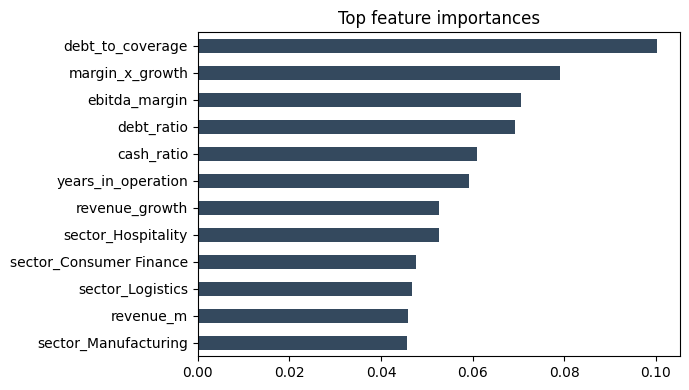

In [8]:
model = make_model().fit(X, y)

explainer = XGBClassifier(n_estimators=400, max_depth=3, learning_rate=0.03,
                          subsample=0.8, colsample_bytree=0.8,
                          eval_metric='logloss', random_state=SEED, n_jobs=4).fit(X, y)

imp = pd.Series(explainer.feature_importances_, index=X.columns).sort_values()
imp.tail(12).plot.barh(figsize=(7, 4), color='#34495e')
plt.title('Top feature importances'); plt.tight_layout(); plt.show()

## 7 — Score the unseen companies

Risk tiers use **data-driven cutoffs**: the 70th and 90th percentile of out-of-fold PD (`MED_CUT=0.16`, `HIGH_CUT=0.34`). On the training set these map to default rates of ~9% (Low) / ~27% (Medium) / ~56% (High), i.e. the High tier isolates the riskiest decile of borrowers rather than relying on a hand-picked threshold.

In [9]:
X_score = build_features(scoring, columns=X.columns)
pd_hat = model.predict_proba(X_score)[:, 1]

def to_tier(p):
    # data-driven cutoffs (OOF p70 / p90), surfaced as module constants
    return pd.cut(p, bins=[-1, MED_CUT, HIGH_CUT, 2], labels=['Low', 'Medium', 'High'])

scoring_out = scoring[['company_id', 'company_name', 'sector', 'country']].copy()
scoring_out['predicted_default_probability'] = pd_hat.round(4)
scoring_out['risk_rating'] = to_tier(pd_hat)
print('PD  min/median/max:', round(pd_hat.min(), 3), round(np.median(pd_hat), 3), round(pd_hat.max(), 3))
print(scoring_out['risk_rating'].value_counts().to_dict())
scoring_out.sort_values('predicted_default_probability', ascending=False).head()

PD  min/median/max: 0.092 0.102 0.572
{'Low': 44, 'Medium': 3, 'High': 3}


,company_id,company_name,sector,country,predicted_default_probability,risk_rating
3,1004,Dune Finance #0004,Hospitality,Luxembourg,0.5723,High
4,1005,Evergreen Holdings #0005,Consumer Finance,Germany,0.4272,High
11,1012,Northstar Finance #0012,Manufacturing,Netherlands,0.3427,High
38,1039,Umbra Partners #0039,Software,Netherlands,0.2384,Medium
40,1041,Aster Holdings #0041,Software,Germany,0.2207,Medium


## 8 — Analyst explanations

For each company I extract the **top risk drivers** from SHAP contributions (signed: which features pushed PD up vs. down, with their actual values) and a **narrative cue** from the business description. These are assembled into a deterministic template, then optionally rewritten into fluent 2–3 sentence analyst prose by an LLM.

In [10]:
FEATURE_LABELS = {
    'revenue_m': 'revenue', 'ebitda_margin': 'EBITDA margin', 'debt_ratio': 'debt ratio',
    'interest_coverage': 'interest coverage', 'cash_ratio': 'cash ratio',
    'years_in_operation': 'years in operation', 'employee_count': 'headcount',
    'revenue_growth': 'revenue growth', 'debt_to_coverage': 'debt-to-coverage ratio',
    'margin_x_growth': 'profitable-growth profile'}

def _label(col):
    if col.startswith('sector_'):  return f"{col[7:]} sector"
    if col.startswith('country_'): return f"operations in {col[8:]}"
    return FEATURE_LABELS.get(col, col)

# SHAP contributions for the scoring set (last column is the bias term)
contribs = explainer.get_booster().predict(xgb.DMatrix(X_score), pred_contribs=True)[:, :-1]
contrib_df = pd.DataFrame(contribs, columns=X.columns)

def narrative_cue(text):
    low = text.lower()
    neg = [p for p in NEG if p in low]
    pos = [p for p in POS if p in low]
    bits = []
    if neg: bits.append('flagged concerns: ' + ', '.join(neg[:2]))
    if pos: bits.append('positives: ' + ', '.join(pos[:2]))
    return '; '.join(bits) if bits else 'no strong qualitative signals'

def driver_phrases(i, k=3):
    row = contrib_df.iloc[i]
    row = row.reindex(row.abs().sort_values(ascending=False).index)
    out = []
    for col in row.index[:k]:
        direction = 'raises' if row[col] > 0 else 'lowers'
        if col in NUMERIC + ENGINEERED and col in scoring.columns:
            out.append(f"{_label(col)} ({scoring.iloc[i][col]:.2f}) {direction} risk")
        else:
            out.append(f"{_label(col)} {direction} risk")
    return out

In [11]:
GROQ_KEY = os.getenv('GROQ_API_KEY')
GROQ_MODEL = 'llama-3.3-70b-versatile'
llm = None
if GROQ_KEY:
    from openai import OpenAI
    llm = OpenAI(api_key=GROQ_KEY, base_url='https://api.groq.com/openai/v1')
    print('LLM explanations: ON (Groq)')
else:
    print('LLM explanations: OFF — using deterministic template (set GROQ_API_KEY in .env to enable)')

def template_explanation(name, pd_prob, tier, drivers, cue):
    return (f"{name} has an estimated PD of {pd_prob:.1%} ({tier} risk). "
            f"Key drivers: {'; '.join(drivers)}. Narrative — {cue}.")

def llm_explanation(name, sector, country, pd_prob, tier, drivers, cue):
    prompt = ("You are a credit risk analyst. In 2-3 concise sentences, explain this company's "
              "default risk. Be specific and reference the drivers. Do not invent numbers.\n\n"
              f"Company: {name} ({sector}, {country})\n"
              f"Estimated PD: {pd_prob:.1%} — {tier} risk tier\n"
              f"Model risk drivers: {'; '.join(drivers)}\n"
              f"Narrative cue: {cue}\n\nRisk assessment:")
    r = llm.chat.completions.create(model=GROQ_MODEL, max_tokens=160, temperature=0.3,
                                    messages=[{'role': 'user', 'content': prompt}])
    return r.choices[0].message.content.strip()

def explain(i):
    r = scoring.iloc[i]
    p, tier = pd_hat[i], str(to_tier(pd_hat)[i])
    drivers, cue = driver_phrases(i), narrative_cue(r['business_description'])
    if llm is not None:
        try:
            return llm_explanation(r['company_name'], r['sector'], r['country'], p, tier, drivers, cue)
        except Exception as e:
            print('  LLM fallback:', e)
    return template_explanation(r['company_name'], p, tier, drivers, cue)

explanations = []
for i in range(len(scoring)):
    explanations.append(explain(i))
    if llm is not None: time.sleep(0.1)
print('generated', len(explanations), 'explanations')
print('\nexample (highest PD):\n', explanations[int(np.argmax(pd_hat))])

LLM explanations: ON (Groq)


generated 50 explanations

example (highest PD):
 Dune Finance #0004 poses a high default risk, driven by its elevated debt ratio and debt-to-coverage ratio, which raise concerns about its ability to manage its debt burden. However, its EBITDA margin partially mitigates this risk, suggesting some capacity for generating earnings. The company's declining revenue and legacy debt burden further exacerbate its default risk, despite the stabilizing effect of its recurring subscription revenue.


## 9 — Output

Saved to `outputs/predictions.csv` with the required schema: `company_id, predicted_default_probability, risk_rating, explanation` (plus name/sector/country for readability).

In [12]:
predictions = scoring_out.copy()
predictions['explanation'] = explanations
predictions = predictions[['company_id', 'company_name', 'sector', 'country',
                           'predicted_default_probability', 'risk_rating', 'explanation']]
predictions.to_csv(OUT / 'predictions.csv', index=False)
print('saved', OUT / 'predictions.csv', predictions.shape)
predictions.sort_values('predicted_default_probability', ascending=False).head(8)

saved outputs/predictions.csv (50, 7)


,company_id,company_name,sector,country,predicted_default_probability,risk_rating,explanation
3,1004,Dune Finance #0004,Hospitality,Luxembourg,0.5723,High,"Dune Finance #0004 poses a high default risk, ..."
4,1005,Evergreen Holdings #0005,Consumer Finance,Germany,0.4272,High,Evergreen Holdings #0005 poses a high default ...
11,1012,Northstar Finance #0012,Manufacturing,Netherlands,0.3427,High,Northstar Finance #0012 poses a high default r...
38,1039,Umbra Partners #0039,Software,Netherlands,0.2384,Medium,Umbra Partners #0039 has a medium risk of defa...
40,1041,Aster Holdings #0041,Software,Germany,0.2207,Medium,Aster Holdings #0041 has a medium risk of defa...
46,1047,Granite Partners #0047,Logistics,Spain,0.1691,Medium,Granite Partners #0047's default risk is moder...
0,1001,Aster Holdings #0001,Manufacturing,Netherlands,0.1515,Low,Aster Holdings #0001 has a relatively low defa...
31,1032,Northstar Finance #0032,Retail,Spain,0.1493,Low,Northstar Finance #0032 has a relatively low d...


## Results, limitations & next steps

**Results.** Calibrated XGBoost on structured financials: **CV AUC 0.766 · Gini 0.531 · KS 0.428 · Brier 0.122**. Predicted PDs are well-calibrated (mean ≈ true base rate). Strongest drivers: debt ratio, EBITDA margin, interest coverage, revenue growth — all economically sensible.

**Why these choices.** Gradient boosting captures non-linear interactions between financial ratios that logistic regression misses; Platt calibration turns the score into a usable PD; CV + Brier keep the evaluation honest on a small dataset.

**Text.** Tested three ways (phrase flags, TF-IDF, embeddings) — no lift. The synthetic label is financial-driven, so narratives are used for *explanations*, not prediction. On real data, narratives often carry genuine signal and I would revisit this.

**Limitations.** Synthetic data with a hidden generating function; only ~1k rows; no temporal/macro information; PD is point-in-time with no calibration to a real default cycle.

**Next Steps**. 
### 1. Macroeconomic Integration & TTC Calibration
* **Action:** Incorporate dynamic macroeconomic features (e.g., central bank interest rates, GDP growth, sector-specific confidence indexes).
* **Impact:** Transition the model from a Point-in-Time (PIT) risk assessment to a Through-the-Cycle (TTC) framework, aligning the pipeline with institutional risk management standards.

### 2. Multimodal LLM-as-a-Feature Architecture (for Real-World Data)
* **Action:** If migrating to non-synthetic data, replace regex/TF-IDF with a domain-specific LLM (e.g., FinBERT) to parse qualitative narratives.
* **Impact:** Extract a continuous financial sentiment/vulnerability index to be fed directly into XGBoost as a tabular feature, unlocking early-warning signals trapped in unstructured text before they manifest in financial ratios.